<a href="https://colab.research.google.com/github/MarkLee1435/Soft-Robotics-263F/blob/Homework1/Homework_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [231]:
import numpy as np
import matplotlib.pyplot as plt

**Explicit Euler Simulation Loop**

# Define Gradients and Hessians

In [232]:
def gradEs(xk, yk, xkp1, ykp1, l_k, k):
    """
    Calculate the gradient of the stretching energy with respect to the coordinates.

    Args:
    - xk (float): x coordinate of the current point
    - yk (float): y coordinate of the current point
    - xkp1 (float): x coordinate of the next point
    - ykp1 (float): y coordinate of the next point
    - l_k (float): reference length
    - EA (float): elastic modulus

    Returns:
    - F (np.array): Gradient array
    """
    F = np.zeros(4)
    F[0] = -(1.0 - np.sqrt((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0) / l_k) * ((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0)**(-0.5) / l_k * (-2.0 * xkp1 + 2.0 * xk)
    F[1] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (-0.2e1 * ykp1 + 0.2e1 * yk)
    F[2] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * xkp1 - 0.2e1 * xk)
    F[3] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * ykp1 - 0.2e1 * yk)

    F = 0.5 * k * l_k * F  # Scale by k and l_k

    return F

In [233]:
def hessEs(xk, yk, xkp1, ykp1, l_k, k):
    """
    This function returns the 4x4 Hessian of the stretching energy E_k^s with
    respect to x_k, y_k, x_{k+1}, and y_{k+1}.
    """
    J = np.zeros((4, 4))  # Initialize the Hessian matrix
    J11 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * xkp1 + 2 * xk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((-2 * xkp1 + 2 * xk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J12 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * ykp1 + 2 * yk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (-2 * ykp1 + 2 * yk) / 0.2e1
    J13 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (2 * xkp1 - 2 * xk) / 0.2e1 + 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J14 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (2 * ykp1 - 2 * yk) / 0.2e1
    J22 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * ykp1 + 2 * yk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((-2 * ykp1 + 2 * yk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J23 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) * (-2 * ykp1 + 2 * yk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * ykp1 + 2 * yk) * (2 * xkp1 - 2 * xk) / 0.2e1
    J24 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (-2 * ykp1 + 2 * yk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * ykp1 + 2 * yk) * (2 * ykp1 - 2 * yk) / 0.2e1 + 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J33 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((2 * xkp1 - 2 * xk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J34 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (2 * xkp1 - 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (2 * xkp1 - 2 * xk) * (2 * ykp1 - 2 * yk) / 0.2e1
    J44 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((2 * ykp1 - 2 * yk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k

    J = np.array([[J11, J12, J13, J14],
                   [J12, J22, J23, J24],
                   [J13, J23, J33, J34],
                   [J14, J24, J34, J44]])

    J *= 0.5 * k * l_k

    return J

# Write Nodes and Properties to Files

In [234]:
%%writefile nodes.txt
0, 0
1, 0
1, -1
2, 0


Overwriting nodes.txt


In [235]:
%%writefile springs.txt
0, 1, 10
0, 2, 5
2, 3, 5
1, 3, 20


Overwriting springs.txt


# Read the nodes, springs, and properties

In [236]:
nodes_file_path = 'nodes.txt'
node_coordinates = []

try:
    with open(nodes_file_path, 'r') as f:
        for line in f:
            # Split each line by comma and remove leading/trailing whitespace
            parts = [part.strip() for part in line.split(',')]
            # Assuming the format is node number, x, y
            # We only need x and y, which are the second and third elements (index 1 and 2)
            if len(parts) == 2:
                try:
                    x = float(parts[0])
                    y = float(parts[1])
                    node_coordinates.append([x, y])
                except ValueError:
                    print(f"Skipping line due to non-numeric coordinates: {line.strip()}")
            else:
                print(f"Skipping line due to incorrect format: {line.strip()}")

    # Convert the list of coordinates to a NumPy array
    node_matrix = np.array(node_coordinates)

    print("Node coordinates successfully loaded into a numpy matrix.")
    display(node_matrix)

except FileNotFoundError:
    print(f"Error: The file '{nodes_file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Node coordinates successfully loaded into a numpy matrix.


array([[ 0.,  0.],
       [ 1.,  0.],
       [ 1., -1.],
       [ 2.,  0.]])

In [237]:
springs_file_path = 'springs.txt'
index_info = []
stiffness_info = []

try:
    with open(springs_file_path, 'r') as f:
        for line in f:
            # Split each line by comma and remove leading/trailing whitespace
            parts = [part.strip() for part in line.split(',')]
            # Assuming the format is spring number, first node, second node, stiffness
            if len(parts) == 3:
                try:
                    first_node_index = float(parts[0])
                    second_node_index = float(parts[1])
                    stiffness = float(parts[2])
                    index_info.append([2*first_node_index, 2*first_node_index+1, 2*second_node_index, 2*second_node_index+1])
                    stiffness_info.append(stiffness)
                except ValueError:
                    print(f"Skipping line due to non-numeric coordinates: {line.strip()}")
            else:
                print(f"Skipping line due to incorrect format: {line.strip()}")

    # Convert the list of coordinates to a NumPy array
    index_matrix = np.array(index_info)
    stiffness_matrix = np.array(stiffness_info)

    print("Spring indices successfully loaded into a numpy matrix.")
    display(index_matrix)

    print("Spring stiffnesses successfully loaded into a numpy matrix.")
    display(stiffness_matrix)

except FileNotFoundError:
    print(f"Error: The file '{springs_file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Spring indices successfully loaded into a numpy matrix.


array([[0., 1., 2., 3.],
       [0., 1., 4., 5.],
       [4., 5., 6., 7.],
       [2., 3., 6., 7.]])

Spring stiffnesses successfully loaded into a numpy matrix.


array([10.,  5.,  5., 20.])

# Equations of motion and Jacobian

In [238]:
def getFexternal(m):

  # Input: mass (m) is a vector of size ndof ( = 2 times number of nodes)
  # Output: weight (W) is a vector of same size

  W = np.zeros_like(m)
  for i in range(len(m) // 2 ):
    W[2 * i] = 0.0
    W[2 * i + 1] = m[2 * i + 1] * (-9.8)
  return W

In [239]:
def getForceJacobian(x_new, x_old, u_old, stiffness_matrix, index_matrix, m, dt, l_k):

  ndof = x_new.shape[0] # number of DOFs

  # Inertia
  f_inertia = m/dt * ((x_new - x_old)/dt - u_old)
  J_inertia = np.diag(m) / dt ** 2

  # Spring
  f_spring = np.zeros_like(x_new)
  J_spring = np.zeros((ndof,ndof))
  for i in range(stiffness_matrix.shape[0]): # loop over each spring
    ind = index_matrix[i].astype(int)
    xi = x_new[ind[0]]
    yi = x_new[ind[1]]
    xj = x_new[ind[2]]
    yj = x_new[ind[3]]
    stiffness = stiffness_matrix[i]
    f_spring[ind] += gradEs(xi, yi, xj, yj, l_k[i], stiffness)
    J_spring[np.ix_(ind, ind)] += hessEs(xi, yi, xj, yj, l_k[i], stiffness)

  # External force
  f_ext = getFexternal(m)
  J_ext = np.zeros((ndof,ndof))

  f = f_inertia + f_spring - f_ext
  J = J_inertia + J_spring - J_ext

  return f, J

# Preparation at t = 0

In [240]:
N = node_matrix.shape[0] # Number of nodes
ndof = 2 * N # Number of degrees of freedom

# Initialize positions, velocities, and accelerations
x_old = np.zeros(ndof)
u_old = np.zeros(ndof)
a_old = np.zeros(ndof)

# Build the position (DOF) vector. Velocity and acceleration remains zero
for i in range(N):
  x_old[2*i] = node_matrix[i][0]
  x_old[2*i+1] = node_matrix[i][1]

# Every spring has a rest length
l_k = np.zeros_like(stiffness_matrix)
for i in range(stiffness_matrix.shape[0]):
  ind = index_matrix[i].astype(int)  # Convert indices to integers
  xi = x_old[ind[0]]
  yi = x_old[ind[1]]
  xj = x_old[ind[2]]
  yj = x_old[ind[3]]
  l_k[i] = np.sqrt((xj - xi)**2 + (yj - yi)**2)

**Mass and Weight**

In [241]:
# Mass
m = np.zeros(ndof)
for i in range(ndof):
  m[i] = 1.0

# Weight
W = getFexternal(m)

# Simulation Loop

**Simulate/integrate function**

In [242]:
# Integrator
def myInt(t_new, x_old, u_old, free_DOF, stiffness_matrix, index_matrix, m, dt):

  # t_new is optional for debugging
  # It should calculate x_new and u_new knowing old positions and velosities
  # free_DOFs is a vector containing the indicies of free variables (not boundary)

  # Guess solution for x_new
  x_new = x_old.copy() # Start with a copy of x_old as the initial guess

  eps = 1.0e-6 # tolerance
  err = eps * 100  # initialize to a large value

  #Newton Raphson
  while err > eps:
    f, J = getForceJacobian(x_new, x_old, u_old, stiffness_matrix, index_matrix, m, dt, l_k)

    #extract free DOFs
    J_free = J[np.ix_(free_DOF, free_DOF)]
    f_free = f[free_DOF]

    #solve for the correction (deltax)
    deltaX_free = np.linalg.solve(J_free, f_free) # The most time consuming step and can be optimized using the sparsity/banded nature of the jacobian

    #construct full deltaX vector
    deltaX = np.zeros_like(x_new)
    deltaX[free_DOF] = deltaX_free

    #update x_new
    x_new = x_new - deltaX

    #calculate error based on the force in free DOFs
    err = np.linalg.norm(f_free)

  u_new = (x_new - x_old) / dt

  return x_new, u_new

**Plotting Function**

In [243]:
def plot(x, index_matrix, t):
  plt.figure() # Create a new figure for each plot
  plt.title(f'Time: {t:.2f} seconds') # Add a title with the current time
  for i in range(index_matrix.shape[0]):
    ind = index_matrix[i].astype(int)  # Convert indices to integers
    xi = x[ind[0]]
    yi = x[ind[1]]
    xj = x[ind[2]]
    yj = x[ind[3]]
    plt.plot([xi, xj], [yi, yj], 'bo-') # Plot a blue line with circles at the nodes
  plt.xlabel('Horizontal Distance (m)')
  plt.ylabel('Vertical Distance (m)')
  plt.axis('equal') # Ensure equal scaling for x and y axes
  plt.grid(True)
  plt.show()

**Main Simulation Loop**

Consider using an input file and calling the script from the termainal so that you can run lots of different configurations at once


**Preparation Work at t=0**

In [244]:
N = node_matrix.shape[0] # Number of nodes
ndof = 2 * N # Number of degrees of freedom

# Initalize my positions and velocities (x_old and u_old; potentially a_old if using Newmark-Beta)

x_old = np.zeros(ndof)
u_old = np.zeros(ndof)

#build x_old vector from the nodes.txt file (node_matrix)

for i in range(N):
  x_old[2*i] = node_matrix[i][0]
  x_old[2*i+1] = node_matrix[i][1] # ycoordinate

#every spring has a rest length
l_k = np.zeros_like(stiffness_matrix)
for i in range(stiffness_matrix.shape[0]):
  ind = index_matrix[i].astype(int)  # Convert indices to integers
  xi = x_old[ind[0]]
  yi = x_old[ind[1]]
  xj = x_old[ind[2]]
  yj = x_old[ind[3]]
  l_k[i] = np.sqrt((xj - xi)**2 + (yj - yi)**2)

# Mass vector
m = np.zeros(ndof)
for i in range(ndof):
  m[i] = 1.0 # in this problem, every point mass is 1kg

# Weight vector
W = getFexternal(m)

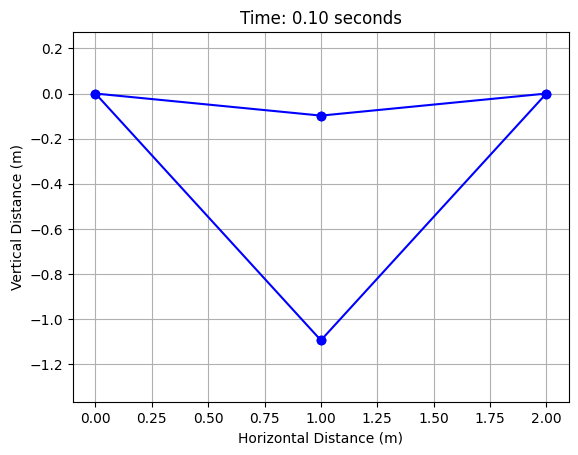

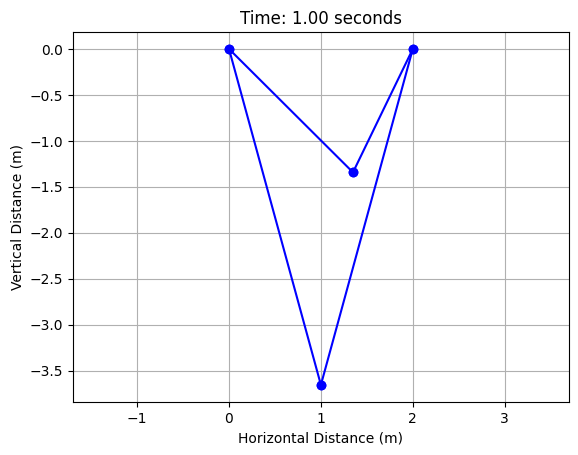

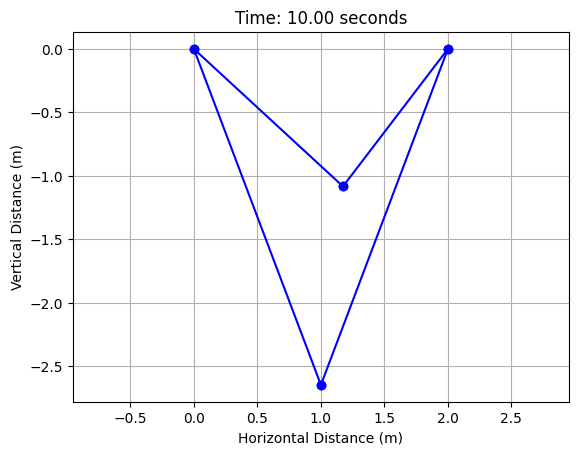

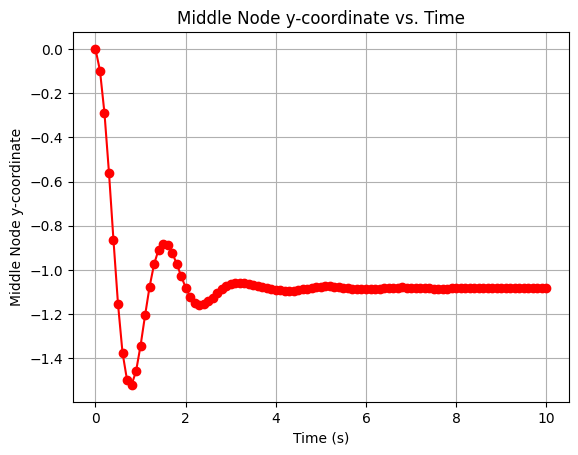

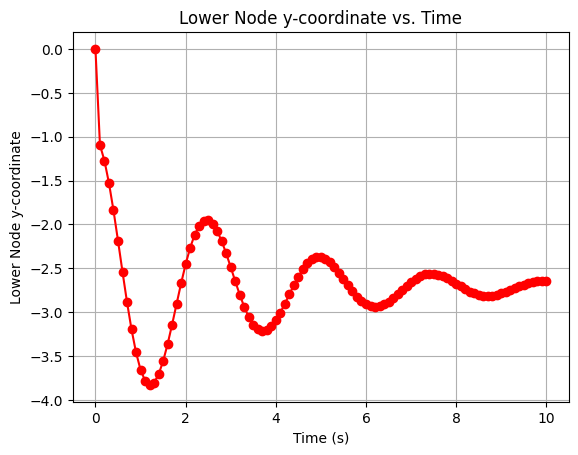

In [245]:
dt = 0.1 # Time step size
maxTime = 10   # total time of simulation
t = np.arange(0, maxTime + dt, dt)

# free indices
free_DOF = np.arange(2, ndof - 2)

# Define times to plot
t_plot = np.array([0, 0.1, 1, 10, 100])

# Container to store y-coordinate of middle node
y_middle = np.zeros(len(t))
y_middle[0] = x_old[3] # y-coordinate of middle node

y_lower = np.zeros(len(t))
y_lower[0] = x_old[3] # y-coordinate of Lower node

for k in range(len(t)-1):
  t_new = t[k+1]

  x_new, u_new = myInt(t_new, x_old, u_old, free_DOF, stiffness_matrix, index_matrix, m, dt)
  if np.any(np.isclose(t_new, t_plot, atol=1e-8)):
    plot(x_new, index_matrix, t_new)
  y_middle[k+1] = x_new[3]
  y_lower[k+1] = x_new[5]

  x_old = x_new
  u_old = u_new

# Plot
plt.figure()
plt.plot(t, y_middle, 'ro-')
plt.xlabel('Time (s)')
plt.ylabel('Middle Node y-coordinate')
plt.title('Middle Node y-coordinate vs. Time')
plt.grid(True)
plt.show()

# Plot
plt.figure()
plt.plot(t, y_lower, 'ro-')
plt.xlabel('Time (s)')
plt.ylabel('Lower Node y-coordinate')
plt.title('Lower Node y-coordinate vs. Time')
plt.grid(True)
plt.show()

In [246]:
# Explicit Euler Integrator with boundary conditions
def myIntExplicit(t_new, x_old, u_old, free_DOF, stiffness_matrix, index_matrix, m, dt, l_k):
    """
    Explicit Euler integrator for the simulation, enforcing fixed DOFs.


  Args:
  - t_new (float): New time
  - x_old (np.array): Old positions
  - u_old (np.array): Old velocities
  - stiffness_matrix (np.array): Stiffness values for each spring
  - index_matrix (np.array): Indices of nodes for each spring
  - m (np.array): Mass vector
  - dt (float): Time step size
  - l_k (np.array): Rest lengths of the springs

  Returns:
  - x_new (np.array): New positions
  - u_new (np.array): New velocities
  """
    ndof = x_old.shape[0]

    # Calculate forces at the current time step
    f_spring = np.zeros_like(x_old)
    for i in range(stiffness_matrix.shape[0]):
        ind = index_matrix[i].astype(int)
        xi = x_old[ind[0]]
        yi = x_old[ind[1]]
        xj = x_old[ind[2]]
        yj = x_old[ind[3]]
        stiffness = stiffness_matrix[i]
        f_spring[ind] += gradEs(xi, yi, xj, yj, l_k[i], stiffness)

    f_ext = getFexternal(m)

    # Net force
    f_net = f_ext - f_spring

    # Acceleration
    a_old = f_net / m

    # Initialize new positions/velocities as a copy
    x_new = x_old.copy()
    u_new = u_old.copy()

    # Update ONLY free DOFs
    u_new[free_DOF] = u_old[free_DOF] + a_old[free_DOF] * dt
    x_new[free_DOF] = x_old[free_DOF] + u_old[free_DOF] * dt

    return x_new, u_new

**Simulation Loop Over Time**

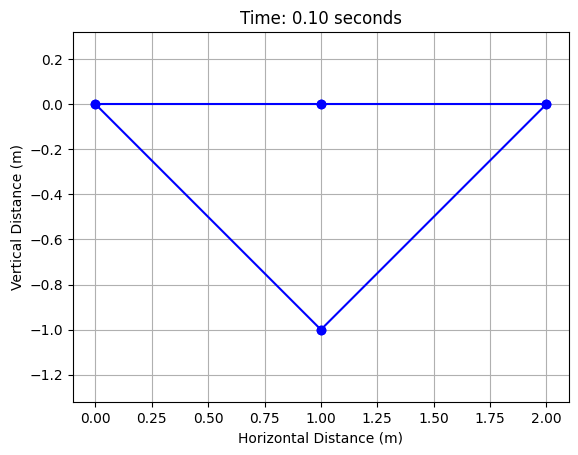

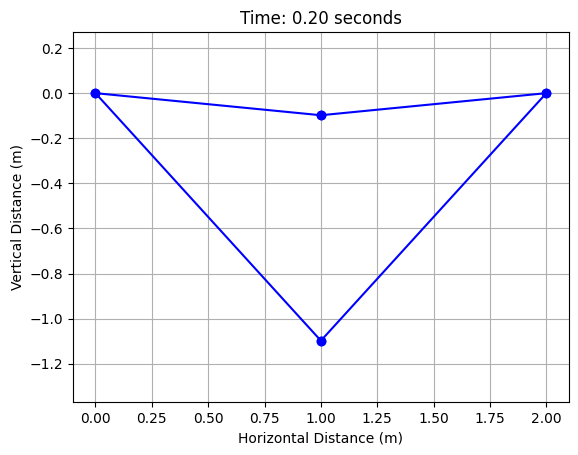

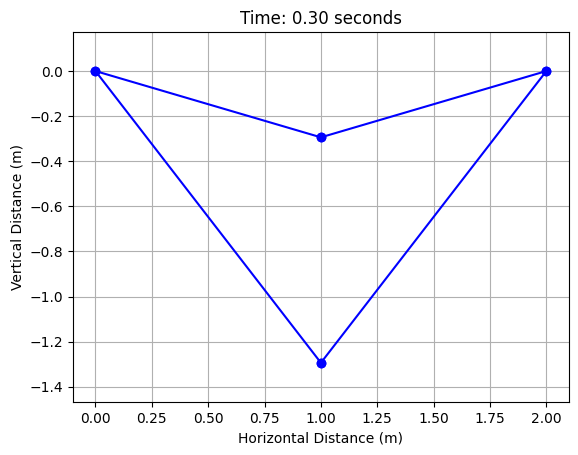

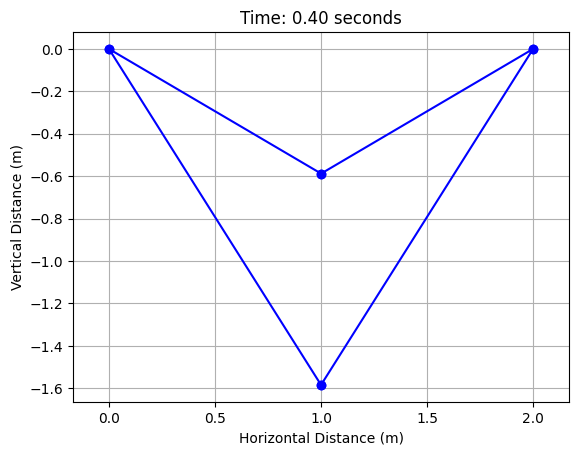

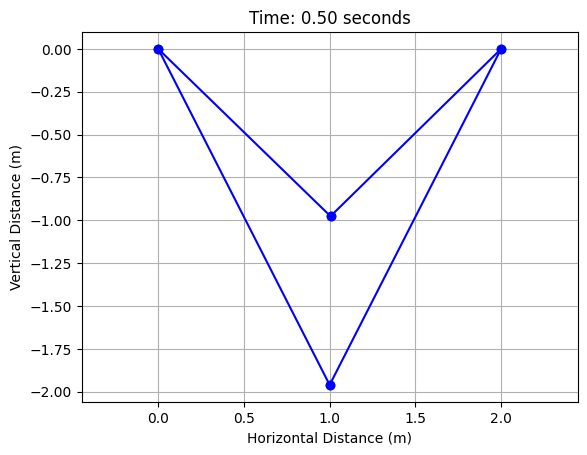

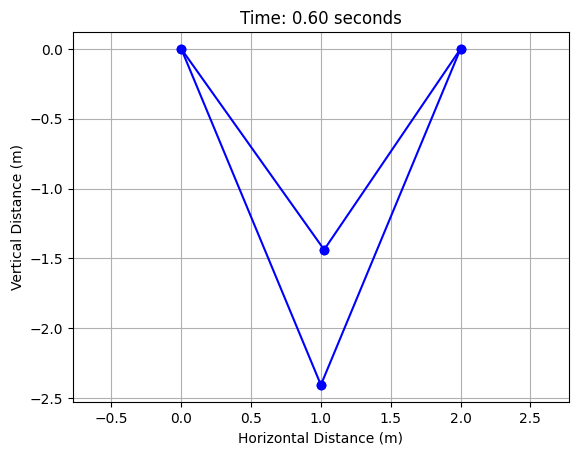

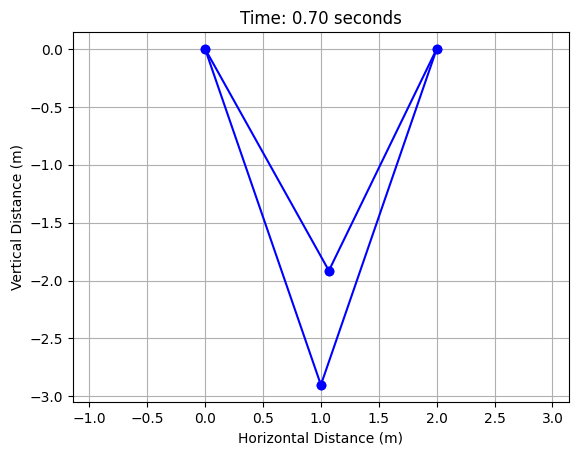

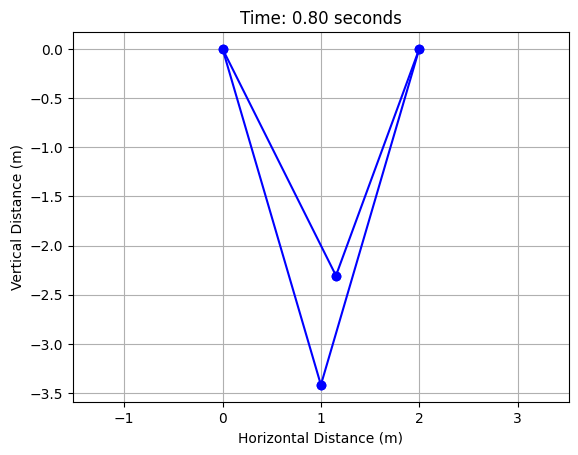

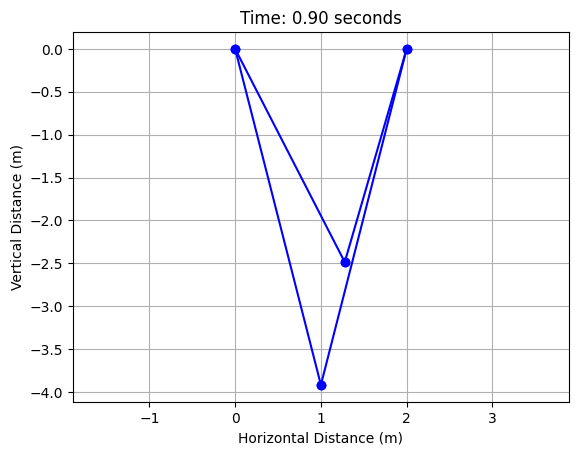

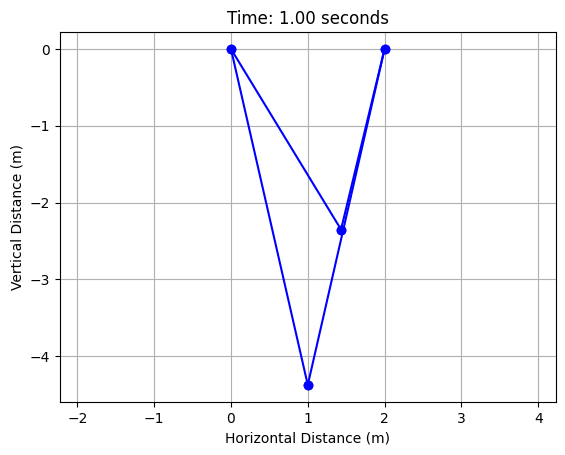

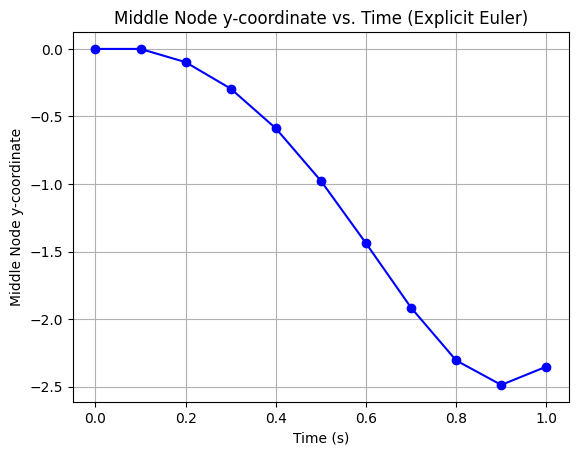

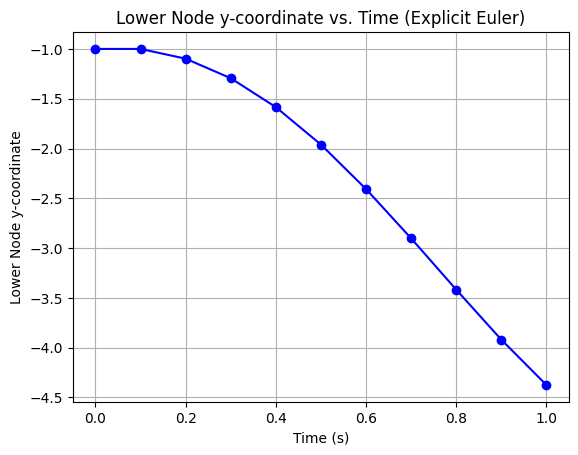

In [247]:
dt_explicit = 0.1  # Time step size for explicit Euler (can be smaller for stability)
maxTime_explicit = 1   # total time of simulation for explicit Euler
t_explicit = np.arange(0, maxTime_explicit + dt_explicit, dt_explicit)

# Initialize positions and velocities for explicit Euler
x_old_explicit = np.zeros(ndof)
u_old_explicit = np.zeros(ndof)

# Build x_old_explicit vector from the nodes.txt file (node_matrix)
for i in range(N):
  x_old_explicit[2*i] = node_matrix[i][0]
  x_old_explicit[2*i+1] = node_matrix[i][1] # ycoordinate

# Container to store y-coordinate of middle and lower nodes for explicit Euler
y_middle_explicit = np.zeros(len(t_explicit))
y_middle_explicit[0] = x_old_explicit[3] # y-coordinate of middle node

y_lower_explicit = np.zeros(len(t_explicit))
y_lower_explicit[0] = x_old_explicit[5] # y-coordinate of lower node

# Explicit Euler Simulation Loop
for k in range(len(t_explicit) - 1):
  t_new_explicit = t_explicit[k+1]

  x_new_explicit, u_new_explicit = myIntExplicit(t_new_explicit, x_old_explicit, u_old_explicit, free_DOF, stiffness_matrix, index_matrix, m, dt_explicit, l_k)

  plot(x_new_explicit, index_matrix, t_new_explicit)

  y_middle_explicit[k+1] = x_new_explicit[3]
  y_lower_explicit[k+1] = x_new_explicit[5]

  x_old_explicit = x_new_explicit
  u_old_explicit = u_new_explicit

# Plotting Explicit Euler Results
plt.figure()
plt.plot(t_explicit, y_middle_explicit, 'bo-')
plt.xlabel('Time (s)')
plt.ylabel('Middle Node y-coordinate')
plt.title('Middle Node y-coordinate vs. Time (Explicit Euler)')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t_explicit, y_lower_explicit, 'bo-')
plt.xlabel('Time (s)')
plt.ylabel('Lower Node y-coordinate')
plt.title('Lower Node y-coordinate vs. Time (Explicit Euler)')
plt.grid(True)
plt.show()

# Newmark–β Solution

In [248]:
# Newmark-Beta Integrator (implicit form, predictor-corrector with Newton-Raphson)
def myIntNewmark(t_new, x_old, u_old, free_DOF,
                 stiffness_matrix, index_matrix, m, dt, l_k,
                 beta=0.25, gamma=0.5, tol=1e-6, maxit=30)

    ndof = x_old.shape[0]

    # --- compute acceleration at old step a_old ---
    # compute spring/internal forces at x_old
    f_spring_old = np.zeros(ndof)
    for i in range(stiffness_matrix.shape[0]):
        ind = index_matrix[i].astype(int)
        xi = x_old[ind[0]]; yi = x_old[ind[1]]
        xj = x_old[ind[2]]; yj = x_old[ind[3]]
        k_i = stiffness_matrix[i]
        f_spring_old[ind] += gradEs(xi, yi, xj, yj, l_k[i], k_i)

    f_ext_old = getFexternal(m)              # external forces (vector)
    f_net_old = f_ext_old - f_spring_old
    a_old = f_net_old / m                    # elementwise division (mass vector)


    x_pred = x_old + dt * u_old + (dt**2) * ((0.5 - beta) * a_old)
    u_pred = u_old + dt * ((1.0 - gamma) * a_old)

    x_new = x_pred.copy()

    # precompute mass term
    coeff_M = 1.0 / (beta * dt**2)

    it = 0
    err = 1e9
    while err > tol and it < maxit:
        # compute internal force and its Jacobian at current x_new

        f_internal, J_internal = getForceJacobian(x_new, x_old, u_old, stiffness_matrix, index_matrix, m, dt, l_k)

        # residual R (full vector)
        a_new_from_x = (x_new - x_old - dt * u_old - (dt**2) * ((0.5 - beta) * a_old)) * coeff_M
        R = m * a_new_from_x - (f_ext_old - f_internal)

        # Restrict to free DOFs for solve
        R_free = R[free_DOF]
        J_sub = J_internal[np.ix_(free_DOF, free_DOF)].copy()

        # Add mass diagonal term
        mass_diag = m[free_DOF] * coeff_M
        for idx_i, val in enumerate(mass_diag):
            J_sub[idx_i, idx_i] += val  # add diagonal mass contribution

        # Solve for delta_x_free: J_sub * deltaX = -R_free
        try:
            deltaX_free = np.linalg.solve(J_sub, -R_free)
        except np.linalg.LinAlgError:

            deltaX_free = np.linalg.lstsq(J_sub, -R_free, rcond=None)[0]

        # assemble full deltaX and update
        deltaX = np.zeros_like(x_new)
        deltaX[free_DOF] = deltaX_free
        x_new += deltaX

        err = np.linalg.norm(R_free)
        it += 1

    # compute final acceleration and velocity
    a_new = (x_new - x_old - dt * u_old - (dt**2) * ((0.5 - beta) * a_old)) * coeff_M
    u_new = u_old + dt * ((1.0 - gamma) * a_old + gamma * a_new)

    # enforce fixed DOFs
    fixed_mask = np.ones(ndof, dtype=bool)
    fixed_mask[free_DOF] = False
    if np.any(fixed_mask):
        x_new[fixed_mask] = x_old[fixed_mask]
        u_new[fixed_mask] = 0.0

    return x_new, u_new


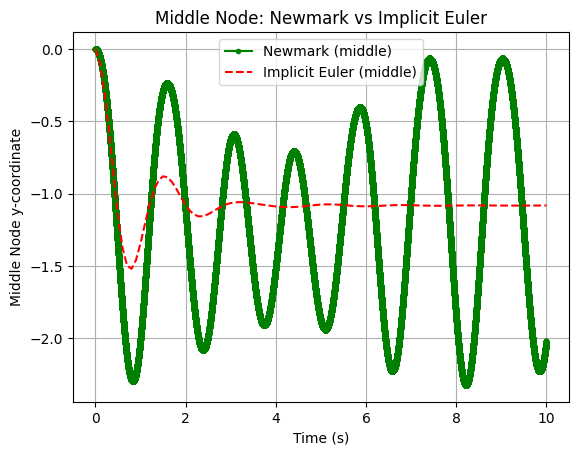

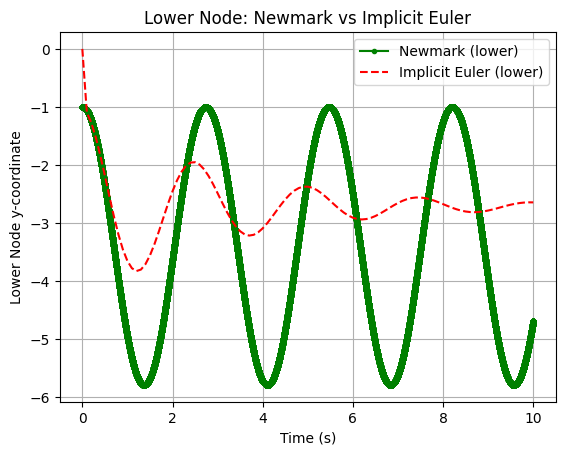

In [249]:

dt_newmark = 0.0001
maxTime_newmark = 10.0
t_newmark = np.arange(0, maxTime_newmark + dt_newmark, dt_newmark)

# initial conditions (reuse your x_old, u_old initializations)
# x_old_nm = starting position vector built from node_matrix (like your explicit example)
x_old_nm = np.zeros(ndof)
u_old_nm = np.zeros(ndof)
for i in range(N):
    x_old_nm[2*i]   = node_matrix[i][0]
    x_old_nm[2*i+1] = node_matrix[i][1]

# Choose free_DOF
free_DOF = np.arange(2, ndof - 2)

# containers for middle/lower node y-coords
y_middle_nm = np.zeros(len(t_newmark))
y_lower_nm  = np.zeros(len(t_newmark))
y_middle_nm[0] = x_old_nm[3]
y_lower_nm[0]  = x_old_nm[5]


for k in range(len(t_newmark) - 1):
    t_n = t_newmark[k+1]
    x_new_nm, u_new_nm = myIntNewmark(t_n, x_old_nm, u_old_nm, free_DOF,
                                      stiffness_matrix, index_matrix, m, dt_newmark, l_k,
                                      beta=0.25, gamma=0.5)

    # if k % 1000 == 0:   # occasional plotting like before
        # plot(x_new_nm, index_matrix, t_n)

    y_middle_nm[k+1] = x_new_nm[3]
    y_lower_nm[k+1]  = x_new_nm[5]

    x_old_nm = x_new_nm
    u_old_nm = u_new_nm

# Plot results (Newmark)
plt.figure()
plt.plot(t_newmark, y_middle_nm, 'g.-', label='Newmark (middle)')
plt.plot(t, y_middle, 'r--', label='Implicit Euler (middle)')
plt.xlabel('Time (s)')
plt.ylabel('Middle Node y-coordinate')
plt.legend()
plt.grid(True)
plt.title('Middle Node: Newmark vs Implicit Euler')
plt.show()

plt.figure()
plt.plot(t_newmark, y_lower_nm, 'g.-', label='Newmark (lower)')
plt.plot(t, y_lower, 'r--', label='Implicit Euler (lower)')   # compare to your implicit traces
plt.xlabel('Time (s)')
plt.ylabel('Lower Node y-coordinate')
plt.legend()
plt.grid(True)
plt.title('Lower Node: Newmark vs Implicit Euler')
plt.show()
